# NB3 — Temporal Dynamics & Fatigue Analysis

**Purpose**: Model how performance changes over the 50-trial sequence within each phase.  
Covers learning curves, speed trends, fatigue detection, AI reliance drift, and carry-over effects.

---

In [1]:
# ── Imports & Setup ──
import sys, os, warnings
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from helpers import (
    load_and_clean, derive_variables, get_participant_summary,
    get_completers, setup_plotting, COLORS, CONDITION_PALETTE, add_significance
)

plt, sns = setup_plotting()

df = load_and_clean()
df = derive_variables(df)

completers = get_completers(df)

# Within-phase trial number (1-50)
df['within_phase_trial'] = ((df['trial_order'] - 1) % 50) + 1
completers['within_phase_trial'] = ((completers['trial_order'] - 1) % 50) + 1

print(f'Total trials: {len(df)}, Completers: {completers["participant_id"].nunique()}')

Total trials: 5950, Completers: 51


## 1. Learning Curves: Accuracy Over Trials

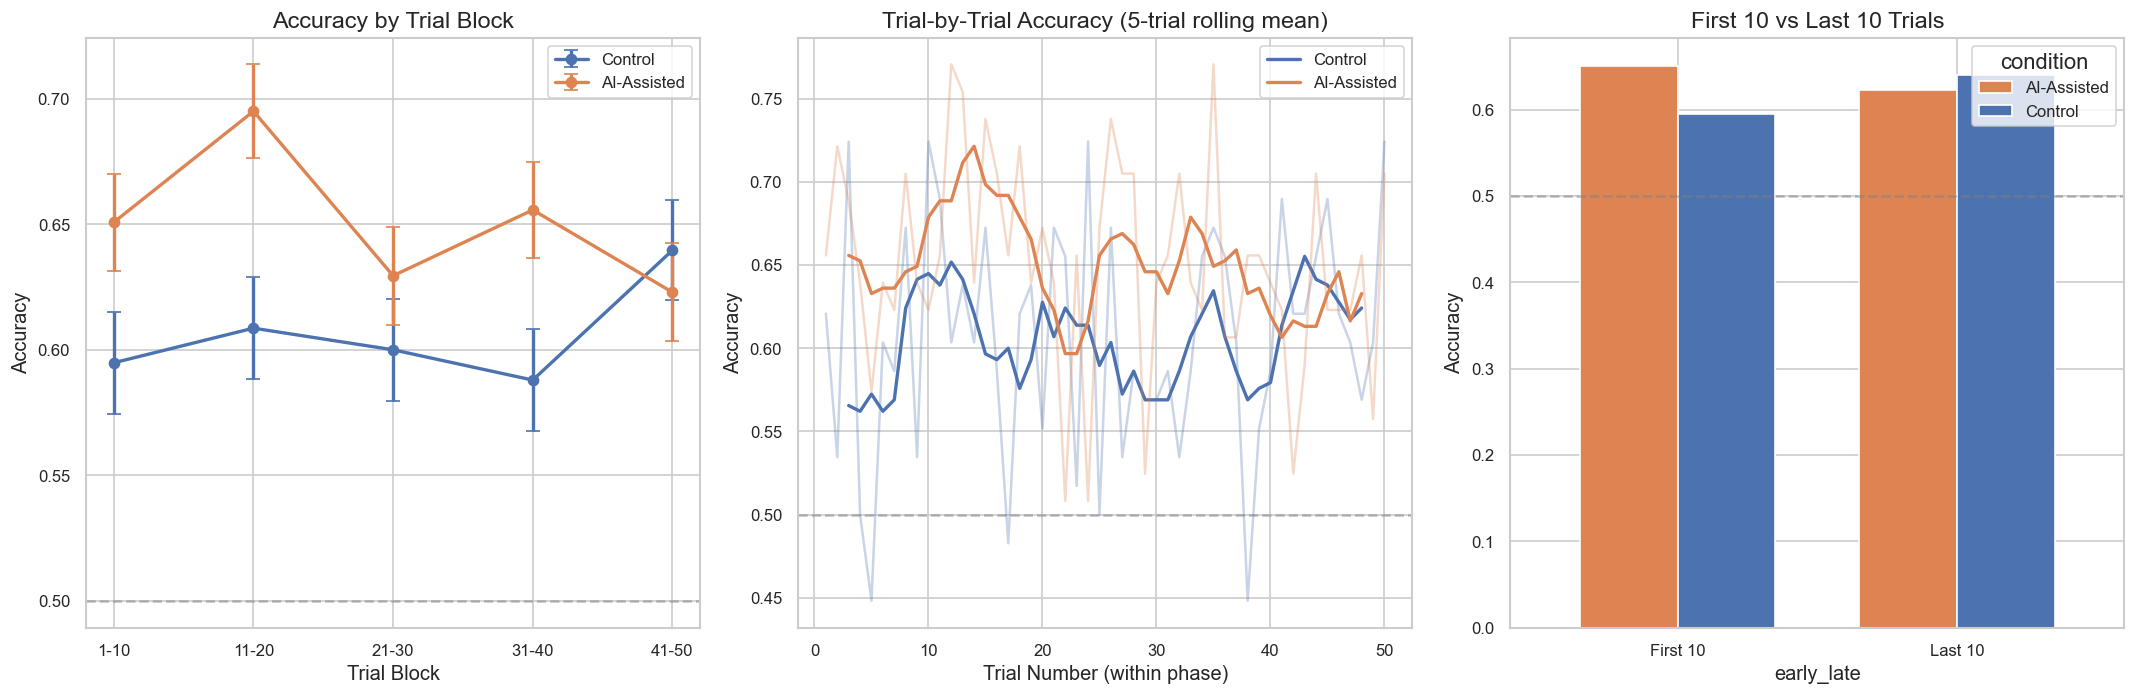

Control: First 10 (0.595) vs Last 10 (0.640): t=-1.571, p=0.1165
AI-Assisted: First 10 (0.651) vs Last 10 (0.623): t=1.012, p=0.3119


In [2]:
# Accuracy by trial block, separated by condition
block_accuracy = df.groupby(['trial_block', 'condition'])['user_correct'].agg(['mean', 'sem', 'count']).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# By condition
for cond, color in CONDITION_PALETTE.items():
    subset = block_accuracy[block_accuracy['condition'] == cond]
    axes[0].errorbar(range(len(subset)), subset['mean'], yerr=subset['sem'],
                    marker='o', label=cond, color=color, linewidth=2, capsize=4)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['1-10', '11-20', '21-30', '31-40', '41-50'])
axes[0].set_xlabel('Trial Block')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by Trial Block')
axes[0].legend()
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Rolling average (5-trial window)
for cond, color in CONDITION_PALETTE.items():
    cond_data = df[df['condition'] == cond]
    rolling = cond_data.groupby('within_phase_trial')['user_correct'].mean()
    axes[1].plot(rolling.index, rolling.values, color=color, alpha=0.3)
    # Smoothed
    smoothed = rolling.rolling(window=5, center=True).mean()
    axes[1].plot(smoothed.index, smoothed.values, color=color, linewidth=2, label=cond)

axes[1].set_xlabel('Trial Number (within phase)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Trial-by-Trial Accuracy (5-trial rolling mean)')
axes[1].legend()
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# First 10 vs last 10 comparison
df['early_late'] = df['within_phase_trial'].apply(lambda x: 'First 10' if x <= 10 else ('Last 10' if x > 40 else 'Middle'))
early_late = df[df['early_late'] != 'Middle'].copy()
el_acc = early_late.groupby(['early_late', 'condition'])['user_correct'].mean().unstack()
el_acc.plot(kind='bar', ax=axes[2], color=[COLORS['ai'], COLORS['control']], width=0.7)
axes[2].set_title('First 10 vs Last 10 Trials')
axes[2].set_ylabel('Accuracy')
axes[2].tick_params(axis='x', rotation=0)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Statistical test: early vs late
for cond in ['Control', 'AI-Assisted']:
    early = df[(df['condition']==cond) & (df['within_phase_trial'] <= 10)]['user_correct']
    late = df[(df['condition']==cond) & (df['within_phase_trial'] > 40)]['user_correct']
    t, p = stats.ttest_ind(early, late)
    print(f'{cond}: First 10 ({early.mean():.3f}) vs Last 10 ({late.mean():.3f}): t={t:.3f}, p={p:.4f}')

## 2. Speed Trends: Trial Duration Over Time

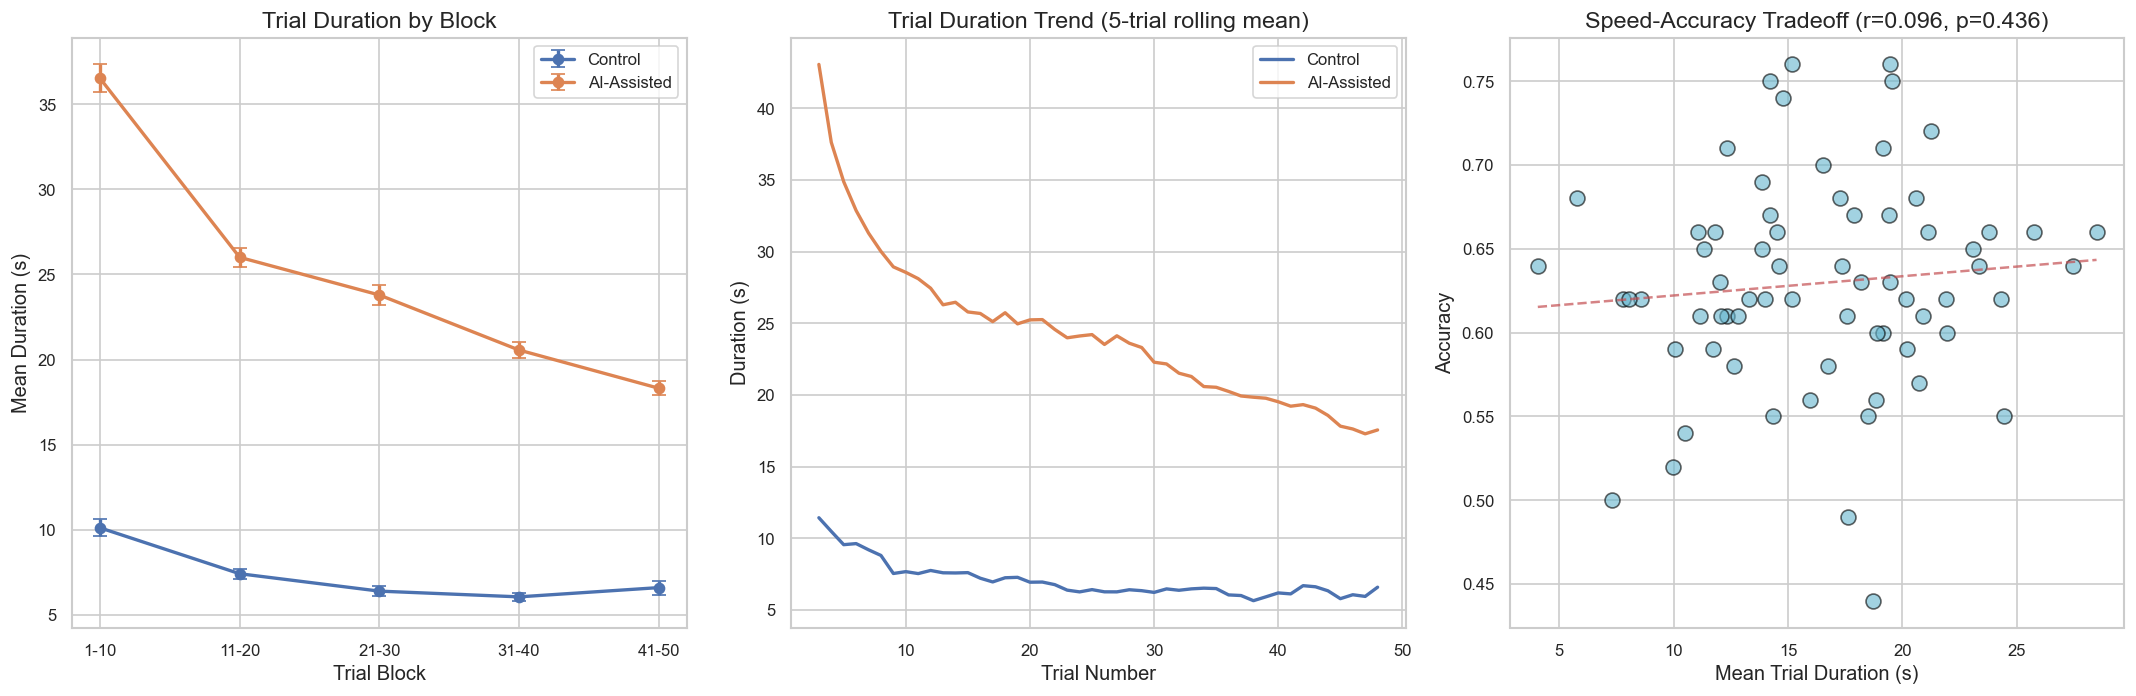

Control duration trend: r=-0.145, p=0.0000 (negative = speeding up)
AI-Assisted duration trend: r=-0.401, p=0.0000 (negative = speeding up)


In [3]:
# Trial duration trends
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# By trial block
block_duration = df.groupby(['trial_block', 'condition'])['trial_duration'].agg(['mean', 'sem']).reset_index()
for cond, color in CONDITION_PALETTE.items():
    subset = block_duration[block_duration['condition'] == cond]
    axes[0].errorbar(range(len(subset)), subset['mean'], yerr=subset['sem'],
                    marker='o', label=cond, color=color, linewidth=2, capsize=4)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['1-10', '11-20', '21-30', '31-40', '41-50'])
axes[0].set_xlabel('Trial Block')
axes[0].set_ylabel('Mean Duration (s)')
axes[0].set_title('Trial Duration by Block')
axes[0].legend()

# Rolling average
for cond, color in CONDITION_PALETTE.items():
    cond_data = df[df['condition'] == cond]
    rolling = cond_data.groupby('within_phase_trial')['trial_duration'].mean()
    smoothed = rolling.rolling(window=5, center=True).mean()
    axes[1].plot(smoothed.index, smoothed.values, color=color, linewidth=2, label=cond)
axes[1].set_xlabel('Trial Number')
axes[1].set_ylabel('Duration (s)')
axes[1].set_title('Trial Duration Trend (5-trial rolling mean)')
axes[1].legend()

# Speed-accuracy tradeoff
p_stats = df.groupby('participant_id').agg(
    mean_duration=('trial_duration', 'mean'),
    accuracy=('user_correct', 'mean')
)
axes[2].scatter(p_stats['mean_duration'], p_stats['accuracy'], 
              alpha=0.6, color=COLORS['neutral'], edgecolor='black', s=80)
r, p_val = stats.pearsonr(p_stats['mean_duration'], p_stats['accuracy'])
# Regression line
z = np.polyfit(p_stats['mean_duration'], p_stats['accuracy'], 1)
x_line = np.linspace(p_stats['mean_duration'].min(), p_stats['mean_duration'].max(), 50)
axes[2].plot(x_line, np.poly1d(z)(x_line), 'r--', alpha=0.7)
axes[2].set_xlabel('Mean Trial Duration (s)')
axes[2].set_ylabel('Accuracy')
axes[2].set_title(f'Speed-Accuracy Tradeoff (r={r:.3f}, p={p_val:.3f})')

plt.tight_layout()
plt.show()

# Linear trend test for duration
for cond in ['Control', 'AI-Assisted']:
    cond_data = df[df['condition'] == cond]
    r, p = stats.pearsonr(cond_data['within_phase_trial'], cond_data['trial_duration'])
    print(f'{cond} duration trend: r={r:.3f}, p={p:.4f} (negative = speeding up)')

## 3. Fatigue Crash Detection

Is there a specific point where accuracy drops sharply?

=== Half-Phase Accuracy Comparison ===
Control: First half (0.604) vs Second half (0.608): t=-0.228, p=0.8197
AI-Assisted: First half (0.658) vs Second half (0.644): t=0.797, p=0.4252


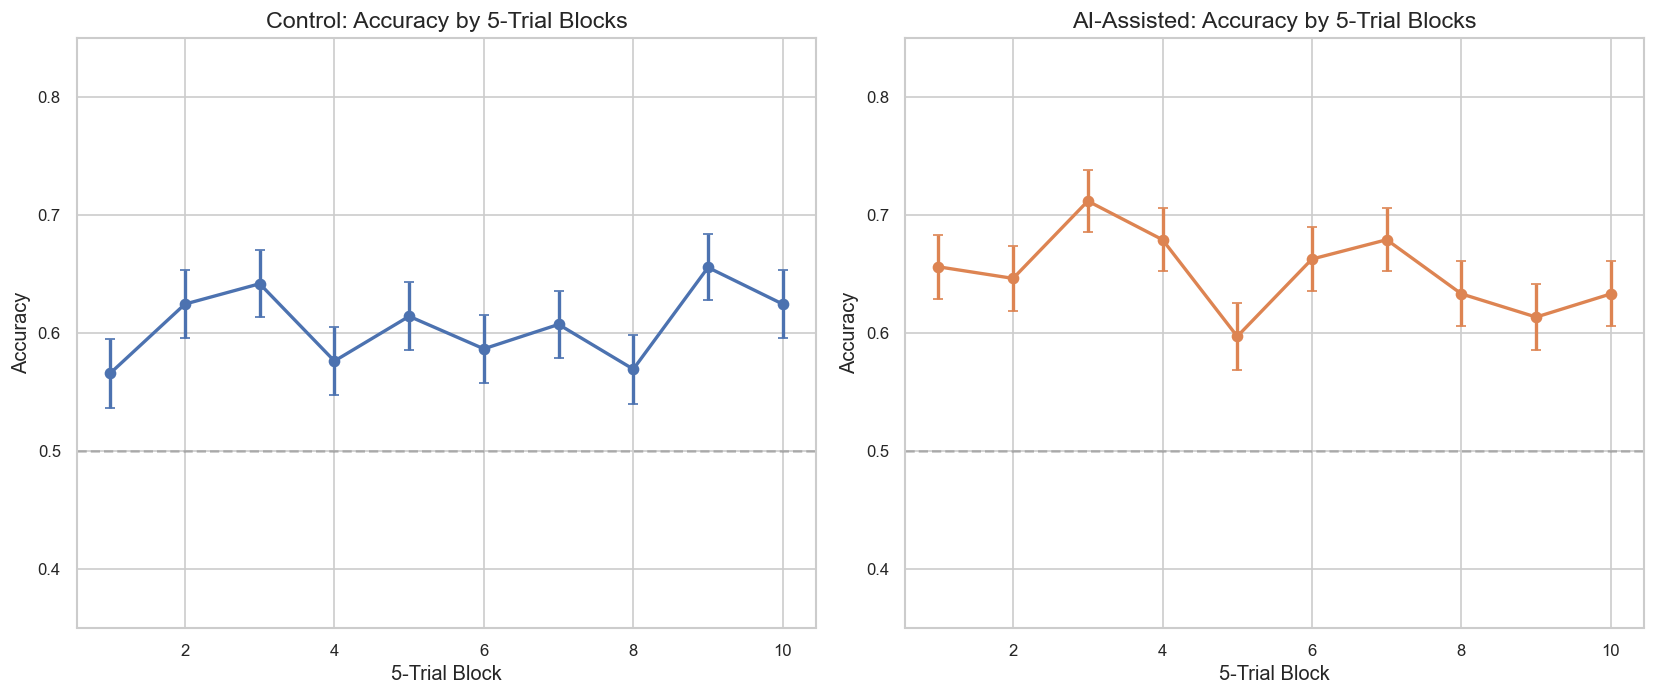

In [4]:
# Segmented approach: compare each half-block
halves = {
    'Trials 1-25': (1, 25),
    'Trials 26-50': (26, 50),
}

print('=== Half-Phase Accuracy Comparison ===')
for cond in ['Control', 'AI-Assisted']:
    cond_data = df[df['condition'] == cond]
    first_half = cond_data[cond_data['within_phase_trial'] <= 25]['user_correct']
    second_half = cond_data[cond_data['within_phase_trial'] > 25]['user_correct']
    t, p = stats.ttest_ind(first_half, second_half)
    print(f'{cond}: First half ({first_half.mean():.3f}) vs Second half ({second_half.mean():.3f}): t={t:.3f}, p={p:.4f}')

# More granular: every 5 trials
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, cond in enumerate(['Control', 'AI-Assisted']):
    cond_data = df[df['condition'] == cond].copy()
    cond_data['block_5'] = pd.cut(cond_data['within_phase_trial'], 
                                  bins=range(0, 55, 5), labels=range(1, 11))
    block_acc = cond_data.groupby('block_5')['user_correct'].agg(['mean', 'sem'])
    
    axes[idx].errorbar(block_acc.index.astype(int), block_acc['mean'], 
                      yerr=block_acc['sem'], marker='o', linewidth=2, capsize=3,
                      color=COLORS['control'] if cond == 'Control' else COLORS['ai'])
    axes[idx].set_xlabel('5-Trial Block')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].set_title(f'{cond}: Accuracy by 5-Trial Blocks')
    axes[idx].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    axes[idx].set_ylim(0.35, 0.85)

plt.tight_layout()
plt.show()

## 4. AI Reliance Over Time

Does over-reliance on AI increase as participants get fatigued?

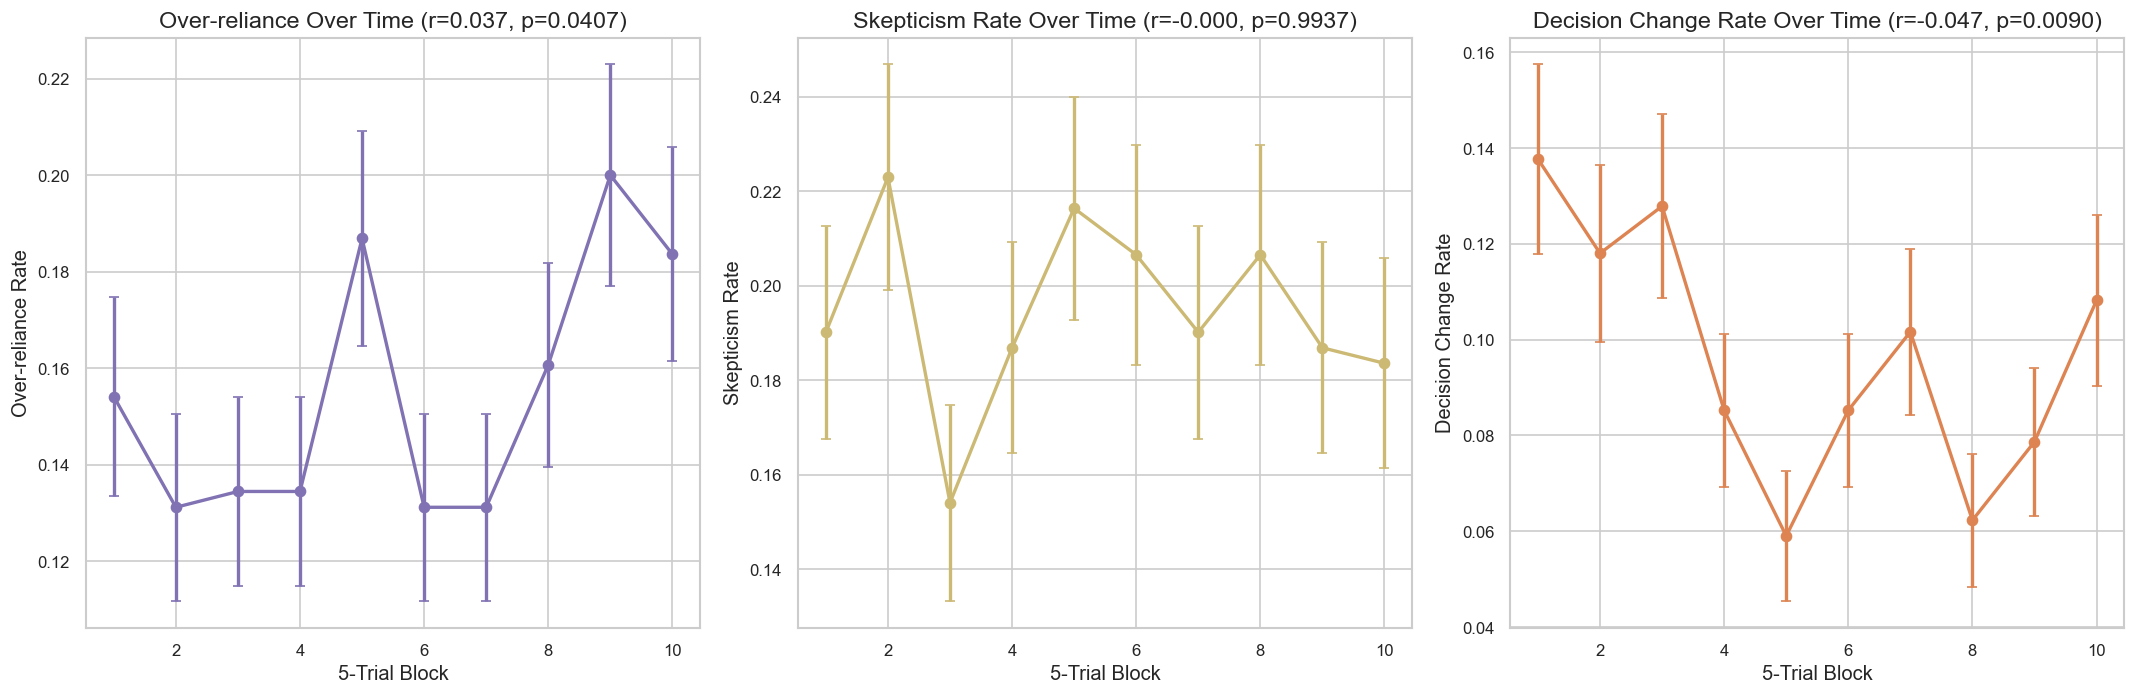

In [5]:
# AI-specific temporal trends
ai_trials = df[df['ai_shown'] == True].copy()
ai_trials['within_phase_trial'] = ((ai_trials['trial_order'] - 1) % 50) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Over-reliance over time
ai_trials['block_5'] = pd.cut(ai_trials['within_phase_trial'], 
                              bins=range(0, 55, 5), labels=range(1, 11))
or_trend = ai_trials.groupby('block_5')['over_reliance'].agg(['mean', 'sem'])
axes[0].errorbar(or_trend.index.astype(int), or_trend['mean'], yerr=or_trend['sem'],
                marker='o', color=COLORS['over_reliance'], linewidth=2, capsize=3)
axes[0].set_title('Over-reliance Rate Over Time')
axes[0].set_xlabel('5-Trial Block')
axes[0].set_ylabel('Over-reliance Rate')

r_or, p_or = stats.pearsonr(
    ai_trials['within_phase_trial'].dropna(), 
    ai_trials['over_reliance'].dropna()
)
axes[0].set_title(f'Over-reliance Over Time (r={r_or:.3f}, p={p_or:.4f})')

# Skepticism over time
sk_trend = ai_trials.groupby('block_5')['skepticism'].agg(['mean', 'sem'])
axes[1].errorbar(sk_trend.index.astype(int), sk_trend['mean'], yerr=sk_trend['sem'],
                marker='o', color=COLORS['skepticism'], linewidth=2, capsize=3)
r_sk, p_sk = stats.pearsonr(
    ai_trials['within_phase_trial'].dropna(),
    ai_trials['skepticism'].dropna()
)
axes[1].set_title(f'Skepticism Rate Over Time (r={r_sk:.3f}, p={p_sk:.4f})')
axes[1].set_xlabel('5-Trial Block')
axes[1].set_ylabel('Skepticism Rate')

# Decision change rate over time
dc_trend = ai_trials.groupby('block_5')['decision_changed'].agg(['mean', 'sem'])
axes[2].errorbar(dc_trend.index.astype(int), dc_trend['mean'], yerr=dc_trend['sem'],
                marker='o', color=COLORS['ai'], linewidth=2, capsize=3)
r_dc, p_dc = stats.pearsonr(
    ai_trials['within_phase_trial'].dropna(),
    ai_trials['decision_changed'].dropna()
)
axes[2].set_title(f'Decision Change Rate Over Time (r={r_dc:.3f}, p={p_dc:.4f})')
axes[2].set_xlabel('5-Trial Block')
axes[2].set_ylabel('Decision Change Rate')

plt.tight_layout()
plt.show()

## 5. Confidence Trends Over Time

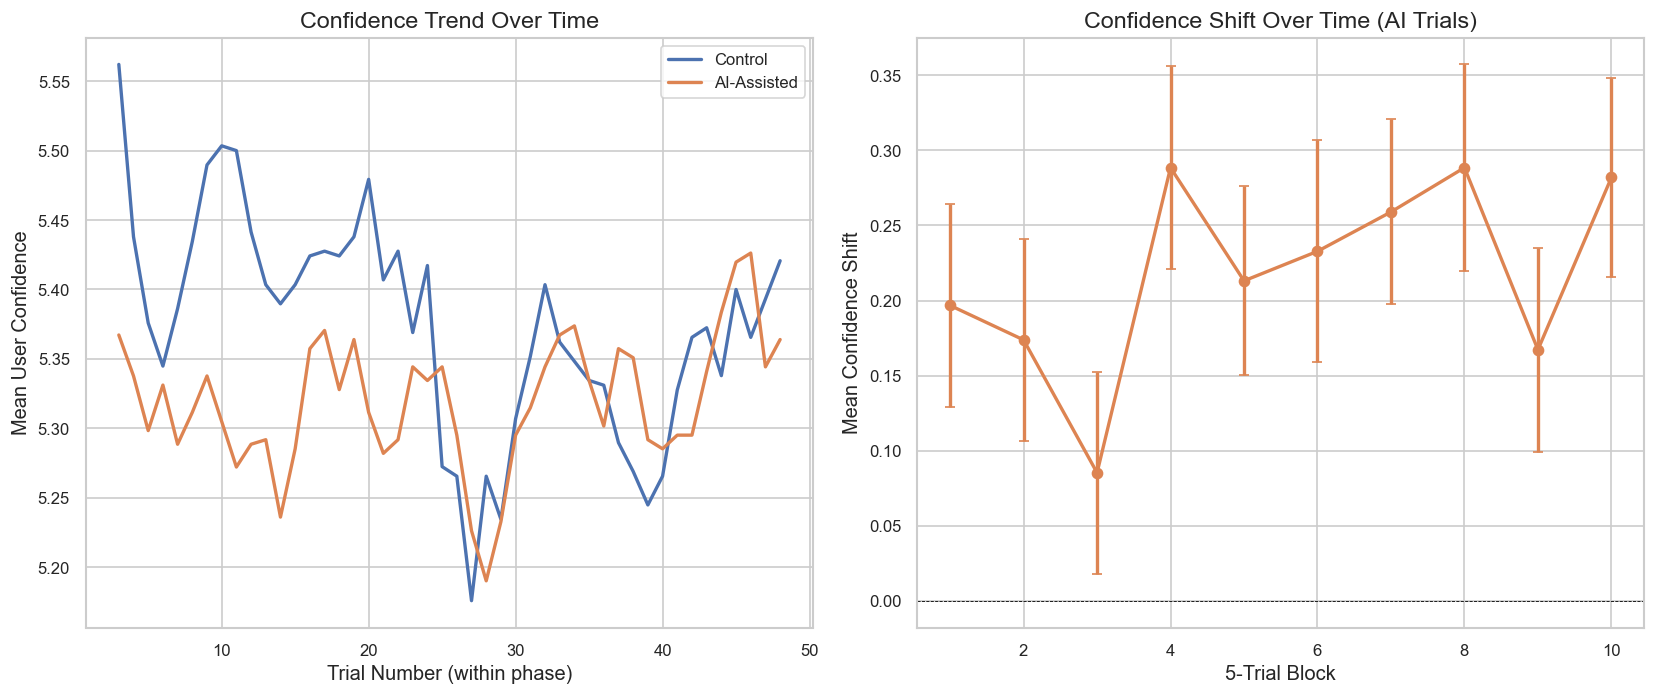

Control confidence trend: r=-0.032, p=0.0879
AI-Assisted confidence trend: r=0.003, p=0.8580


In [6]:
# Confidence trends
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# User confidence over time by condition
for cond, color in CONDITION_PALETTE.items():
    cond_data = df[df['condition'] == cond].copy()
    cond_data['within_phase_trial'] = ((cond_data['trial_order'] - 1) % 50) + 1
    rolling = cond_data.groupby('within_phase_trial')['user_confidence'].mean()
    smoothed = rolling.rolling(window=5, center=True).mean()
    axes[0].plot(smoothed.index, smoothed.values, color=color, linewidth=2, label=cond)

axes[0].set_xlabel('Trial Number (within phase)')
axes[0].set_ylabel('Mean User Confidence')
axes[0].set_title('Confidence Trend Over Time')
axes[0].legend()

# Confidence shift trend (AI trials only)
conf_shift_trend = ai_trials.groupby('block_5')['confidence_shift'].agg(['mean', 'sem'])
axes[1].errorbar(conf_shift_trend.index.astype(int), conf_shift_trend['mean'],
                yerr=conf_shift_trend['sem'], marker='o', color=COLORS['ai'],
                linewidth=2, capsize=3)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_xlabel('5-Trial Block')
axes[1].set_ylabel('Mean Confidence Shift')
axes[1].set_title('Confidence Shift Over Time (AI Trials)')

plt.tight_layout()
plt.show()

# Linear trend test for confidence
for cond in ['Control', 'AI-Assisted']:
    cond_data = df[df['condition'] == cond].copy()
    cond_data['within_phase_trial'] = ((cond_data['trial_order'] - 1) % 50) + 1
    r, p = stats.pearsonr(cond_data['within_phase_trial'], cond_data['user_confidence'])
    print(f'{cond} confidence trend: r={r:.3f}, p={p:.4f}')

## 6. Carry-Over Effects (Completers Only)

For completers: does Phase 1 experience affect Phase 2 performance?

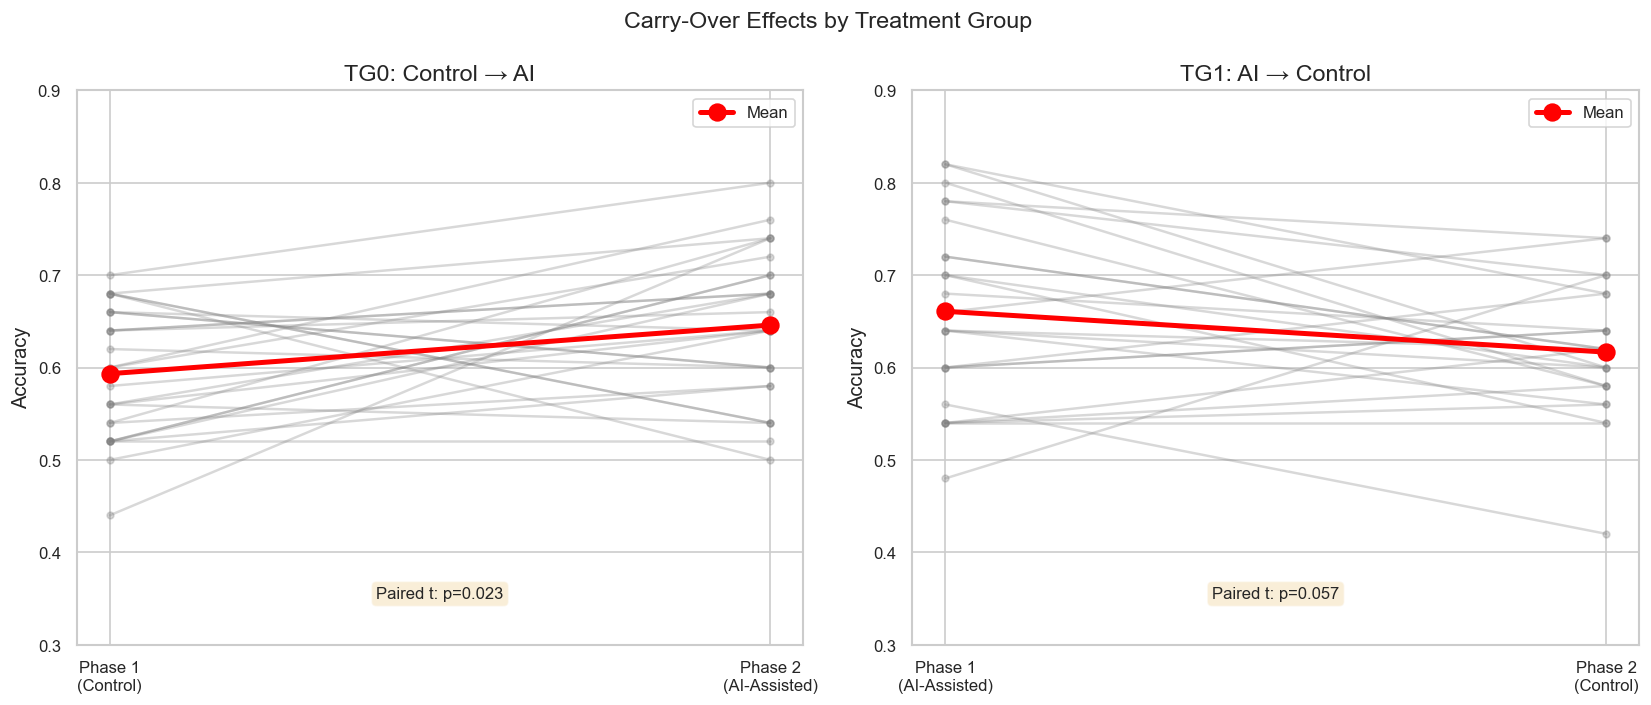

=== TG0: Control → AI ===
Phase 1 Mean Accuracy: 0.5933
Phase 2 Mean Accuracy: 0.6459
Paired t-test: t=2.4179, p=0.0229

=== TG1: AI → Control ===
Phase 1 Mean Accuracy: 0.6608
Phase 2 Mean Accuracy: 0.6167
Paired t-test: t=-2.0045, p=0.0569



In [7]:
# Carry-over: compare Phase 1 vs Phase 2 performance by treatment group
ps = get_participant_summary(df)
ps_comp = ps[ps['is_completer']].copy()

# Phase 1 vs Phase 2 accuracy per treatment group
phase_data = completers.groupby(['participant_id', 'phase', 'treatment_group'])['user_correct'].mean().reset_index()
phase_pivot = phase_data.pivot_table(index=['participant_id', 'treatment_group'], 
                                      columns='phase', values='user_correct').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (tg, label) in enumerate([('0', 'TG0: Control → AI'), ('1', 'TG1: AI → Control')]):
    subset = phase_pivot[phase_pivot['treatment_group'] == tg]
    for _, row in subset.iterrows():
        axes[idx].plot([0, 1], [row['Phase 1'], row['Phase 2']], 'o-', 
                      alpha=0.3, color='gray', markersize=4)
    axes[idx].plot([0, 1], [subset['Phase 1'].mean(), subset['Phase 2'].mean()],
                 'o-', color='red', linewidth=3, markersize=10, label='Mean', zorder=5)
    axes[idx].set_xticks([0, 1])
    
    # Label with condition
    if tg == '0':
        axes[idx].set_xticklabels(['Phase 1\n(Control)', 'Phase 2\n(AI-Assisted)'])
    else:
        axes[idx].set_xticklabels(['Phase 1\n(AI-Assisted)', 'Phase 2\n(Control)'])
    
    axes[idx].set_ylabel('Accuracy')
    axes[idx].set_title(label)
    axes[idx].legend()
    axes[idx].set_ylim(0.3, 0.9)
    
    # Test phase difference
    t, p = stats.ttest_rel(subset['Phase 2'], subset['Phase 1'])
    axes[idx].text(0.5, 0.35, f'Paired t: p={p:.3f}', ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Carry-Over Effects by Treatment Group', fontsize=14)
plt.tight_layout()
plt.show()

# Test phase difference
# 1. Control to AI (TG0)
subset_tg0 = phase_pivot[phase_pivot['treatment_group'] == '0']
t0, p0 = stats.ttest_rel(subset_tg0['Phase 2'], subset_tg0['Phase 1'])

print('=== TG0: Control → AI ===')
print(f"Phase 1 Mean Accuracy: {subset_tg0['Phase 1'].mean():.4f}")
print(f"Phase 2 Mean Accuracy: {subset_tg0['Phase 2'].mean():.4f}")
print(f'Paired t-test: t={t0:.4f}, p={p0:.4f}\n')


# 2. AI to Control (TG1)
subset_tg1 = phase_pivot[phase_pivot['treatment_group'] == '1']
t1, p1 = stats.ttest_rel(subset_tg1['Phase 2'], subset_tg1['Phase 1'])

print('=== TG1: AI → Control ===')
print(f"Phase 1 Mean Accuracy: {subset_tg1['Phase 1'].mean():.4f}")
print(f"Phase 2 Mean Accuracy: {subset_tg1['Phase 2'].mean():.4f}")
print(f'Paired t-test: t={t1:.4f}, p={p1:.4f}\n')


## 6b. Learning Effect: Does AI Exposure Improve Subsequent

§6b. Learning Effect Investigation
 

COMPARISON: TG1 Control (Phase 2, AFTER AI) vs TG0 Control (Phase 1, NO prior AI)
  TG0 Control: M=0.593, SD=0.071, n=27
  TG1 Control: M=0.617, SD=0.071, n=24
  Difference:  0.023
  Independent t-test: t=1.174, p=0.2463
  Mann-Whitney (TG1 > TG0): U=386.0, p=0.1219
  Cohen's d: 0.329

--- Learning Curve: TG1 Control (after AI) vs TG0 Control (no prior AI) ---
Block        TG0 (naive)      TG1 (post-AI)    Diff    
----------------------------------------------------
  1-10       0.585 ± 0.154  0.617 ± 0.190  +0.031
  11-20       0.589 ± 0.176  0.621 ± 0.150  +0.032
  21-30       0.615 ± 0.179  0.571 ± 0.127  -0.044
  31-40       0.574 ± 0.138  0.579 ± 0.141  +0.005
  41-50       0.604 ± 0.122  0.696 ± 0.123  +0.092

TG1: AI accuracy → Control accuracy: r=0.195, p=0.3603
  (positive r = those who performed better WITH AI also do better WITHOUT it)

--- Carry-Over Detail ---
TG0 (Control→AI):
  Phase 1 Control: 0.593
  Phase 2 AI:      0.646
  Chang

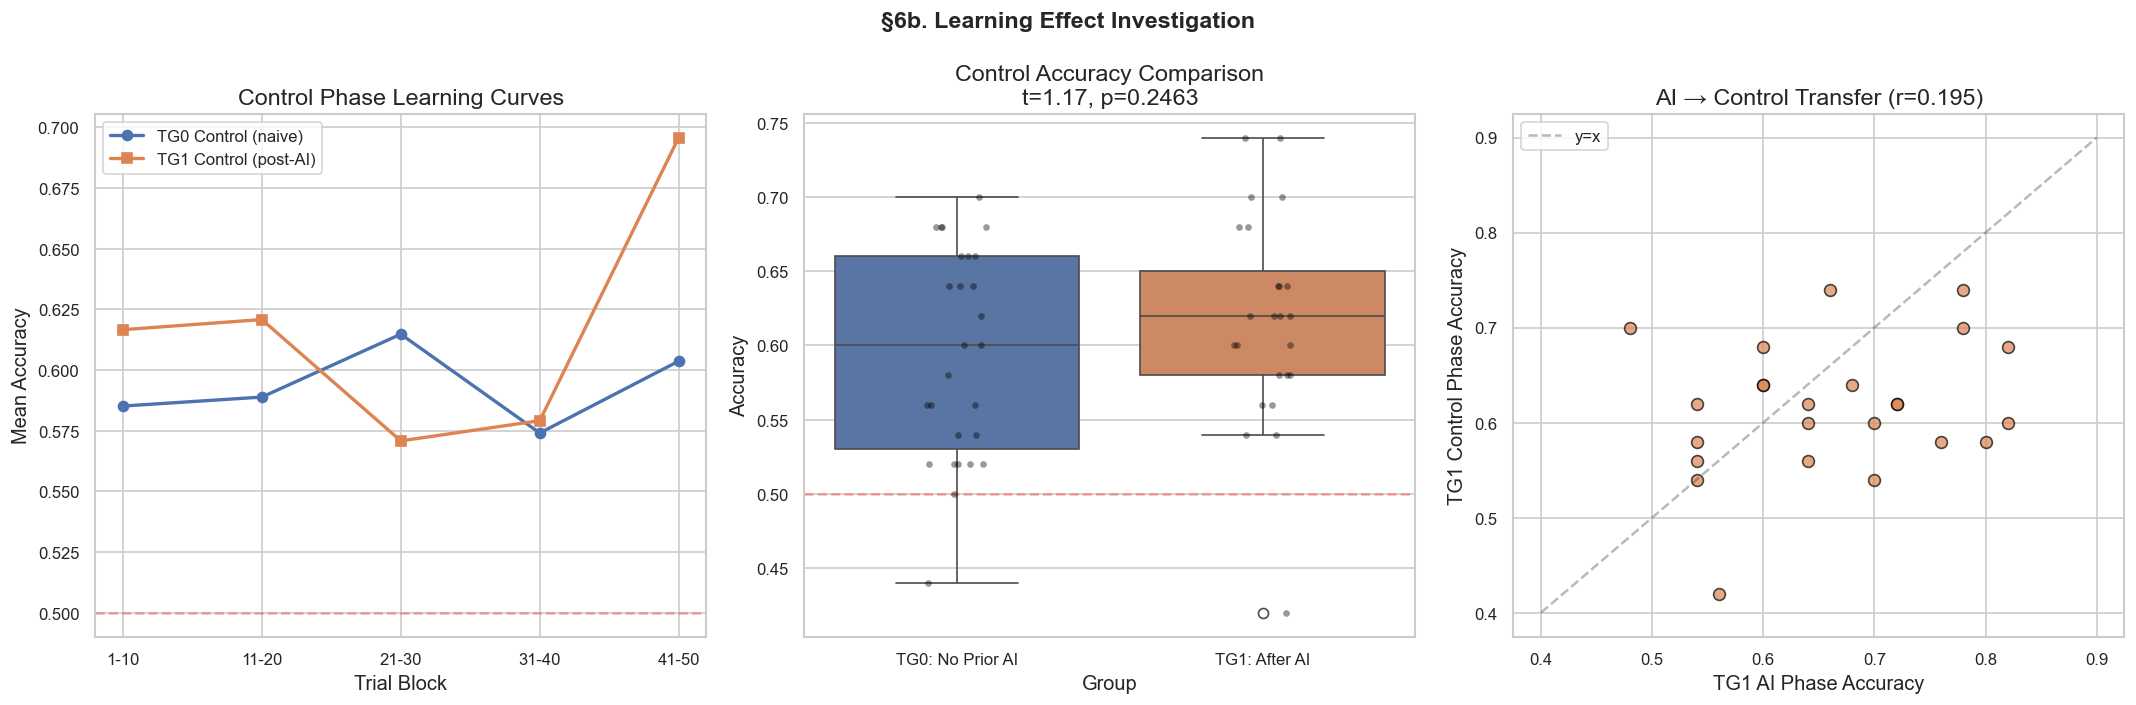

In [8]:
from scipy.stats import ttest_ind, mannwhitneyu, spearmanr

completers = df[df['is_completer']].copy()

# KEY COMPARISON:
# TG1 participants did AI first (Phase 1), then Control (Phase 2).
# TG0 participants did Control first (Phase 1).
# If AI teaches something, TG1's Control accuracy (Phase 2) should be
# HIGHER than TG0's Control accuracy (Phase 1).

tg0_control = completers[
    (completers['treatment_group'].str.startswith('0')) &
    (completers['condition'] == 'Control')
]
tg1_control = completers[
    (completers['treatment_group'].str.startswith('1')) &
    (completers['condition'] == 'Control')
]

tg0_ctrl_acc = tg0_control.groupby('participant_id')['user_correct'].mean()
tg1_ctrl_acc = tg1_control.groupby('participant_id')['user_correct'].mean()

t_stat, p_val = ttest_ind(tg1_ctrl_acc, tg0_ctrl_acc)
u_stat, p_u = mannwhitneyu(tg1_ctrl_acc, tg0_ctrl_acc, alternative='greater')
pooled_sd = ((tg0_ctrl_acc.std()**2 + tg1_ctrl_acc.std()**2) / 2) ** 0.5
cohens_d = (tg1_ctrl_acc.mean() - tg0_ctrl_acc.mean()) / pooled_sd

print("§6b. Learning Effect Investigation")
print(" ")
print()
print("COMPARISON: TG1 Control (Phase 2, AFTER AI) vs TG0 Control (Phase 1, NO prior AI)")
print(f"  TG0 Control: M={tg0_ctrl_acc.mean():.3f}, SD={tg0_ctrl_acc.std():.3f}, "
      f"n={len(tg0_ctrl_acc)}")
print(f"  TG1 Control: M={tg1_ctrl_acc.mean():.3f}, SD={tg1_ctrl_acc.std():.3f}, "
      f"n={len(tg1_ctrl_acc)}")
print(f"  Difference:  {tg1_ctrl_acc.mean() - tg0_ctrl_acc.mean():.3f}")
print(f"  Independent t-test: t={t_stat:.3f}, p={p_val:.4f}")
print(f"  Mann-Whitney (TG1 > TG0): U={u_stat:.1f}, p={p_u:.4f}")
print(f"  Cohen's d: {cohens_d:.3f}")
print()

# --- Learning curve within TG1's Control phase ---
# If there's a learning effect, TG1 should start their Control phase strong
tg1_control_sorted = tg1_control.sort_values(['participant_id', 'trial_end_time']).copy()
tg1_control_sorted['within_phase_trial'] = (
    tg1_control_sorted.groupby('participant_id').cumcount() + 1
)

tg0_control_sorted = tg0_control.sort_values(['participant_id', 'trial_end_time']).copy()
tg0_control_sorted['within_phase_trial'] = (
    tg0_control_sorted.groupby('participant_id').cumcount() + 1
)

blocks = [(1, 10), (11, 20), (21, 30), (31, 40), (41, 50)]
print("--- Learning Curve: TG1 Control (after AI) vs TG0 Control (no prior AI) ---")
print(f"{'Block':<12} {'TG0 (naive)':<16} {'TG1 (post-AI)':<16} {'Diff':<8}")
print("-" * 52)
for start, end in blocks:
    tg0_block = tg0_control_sorted[
        (tg0_control_sorted['within_phase_trial'] >= start) &
        (tg0_control_sorted['within_phase_trial'] <= end)
    ].groupby('participant_id')['user_correct'].mean()
    tg1_block = tg1_control_sorted[
        (tg1_control_sorted['within_phase_trial'] >= start) &
        (tg1_control_sorted['within_phase_trial'] <= end)
    ].groupby('participant_id')['user_correct'].mean()
    diff = tg1_block.mean() - tg0_block.mean()
    print(f"  {start}-{end:<8} {tg0_block.mean():.3f} ± {tg0_block.std():.3f}  "
          f"{tg1_block.mean():.3f} ± {tg1_block.std():.3f}  {diff:+.3f}")
print()

# --- Does TG1's AI phase accuracy predict their Control phase accuracy? ---
tg1_ps = get_participant_summary(completers[completers['treatment_group'].str.startswith('1')])
if len(tg1_ps) > 5:
    r, p = spearmanr(tg1_ps['ai_accuracy'], tg1_ps['control_accuracy'])
    print(f"TG1: AI accuracy → Control accuracy: r={r:.3f}, p={p:.4f}")
    print("  (positive r = those who performed better WITH AI also do better WITHOUT it)")
    print()

# --- Also: TG0's Phase 1 (Control) → Phase 2 (AI) improvement ---
tg0_ps = get_participant_summary(completers[completers['treatment_group'].str.startswith('0')])
print("--- Carry-Over Detail ---")
print(f"TG0 (Control→AI):")
print(f"  Phase 1 Control: {tg0_ps['control_accuracy'].mean():.3f}")
print(f"  Phase 2 AI:      {tg0_ps['ai_accuracy'].mean():.3f}")
print(f"  Change:          {tg0_ps['ai_accuracy'].mean() - tg0_ps['control_accuracy'].mean():+.3f}")
print()
print(f"TG1 (AI→Control):")
print(f"  Phase 1 AI:      {tg1_ps['ai_accuracy'].mean():.3f}")
print(f"  Phase 2 Control: {tg1_ps['control_accuracy'].mean():.3f}")
print(f"  Change:          {tg1_ps['control_accuracy'].mean() - tg1_ps['ai_accuracy'].mean():+.3f}")
print()
print("INTERPRETATION:")
print("  If TG1's Control accuracy is NOT significantly below their AI accuracy,")
print("  this suggests a LEARNING EFFECT: the AI helped them develop skills")
print("  that persisted even after AI was removed.")
print("  Compare TG1 Control to TG0 Control for the strongest evidence.")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Block-by-block comparison
tg0_means, tg1_means = [], []
for start, end in blocks:
    tg0_b = tg0_control_sorted[
        (tg0_control_sorted['within_phase_trial'] >= start) &
        (tg0_control_sorted['within_phase_trial'] <= end)
    ].groupby('participant_id')['user_correct'].mean().mean()
    tg1_b = tg1_control_sorted[
        (tg1_control_sorted['within_phase_trial'] >= start) &
        (tg1_control_sorted['within_phase_trial'] <= end)
    ].groupby('participant_id')['user_correct'].mean().mean()
    tg0_means.append(tg0_b)
    tg1_means.append(tg1_b)

block_labels = [f'{s}-{e}' for s, e in blocks]
x = range(len(blocks))
axes[0].plot(x, tg0_means, 'o-', color=COLORS['control'], label='TG0 Control (naive)', lw=2)
axes[0].plot(x, tg1_means, 's-', color=COLORS['ai'], label='TG1 Control (post-AI)', lw=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(block_labels)
axes[0].set_xlabel('Trial Block')
axes[0].set_ylabel('Mean Accuracy')
axes[0].set_title('Control Phase Learning Curves')
axes[0].legend()
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.3)

# Box comparison
import matplotlib.patches as mpatches
data_comp = pd.DataFrame({
    'Accuracy': list(tg0_ctrl_acc) + list(tg1_ctrl_acc),
    'Group': (['TG0: No Prior AI'] * len(tg0_ctrl_acc) +
              ['TG1: After AI'] * len(tg1_ctrl_acc))
})
sns.boxplot(data=data_comp, x='Group', y='Accuracy', ax=axes[1],
            palette=[COLORS['control'], COLORS['ai']])
sns.stripplot(data=data_comp, x='Group', y='Accuracy', ax=axes[1],
              color='black', alpha=0.4, size=4)
axes[1].set_title(f'Control Accuracy Comparison\nt={t_stat:.2f}, p={p_val:.4f}')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.3)

# Scatter: TG1 AI accuracy → TG1 Control accuracy
if len(tg1_ps) > 5:
    axes[2].scatter(tg1_ps['ai_accuracy'], tg1_ps['control_accuracy'],
                    c=COLORS['ai'], edgecolors='black', s=50, alpha=0.7)
    axes[2].plot([0.4, 0.9], [0.4, 0.9], 'k--', alpha=0.3, label='y=x')
    axes[2].set_xlabel('TG1 AI Phase Accuracy')
    axes[2].set_ylabel('TG1 Control Phase Accuracy')
    axes[2].set_title(f'AI → Control Transfer (r={r:.3f})')
    axes[2].legend()

plt.suptitle('§6b. Learning Effect Investigation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Reversion Rate Trends

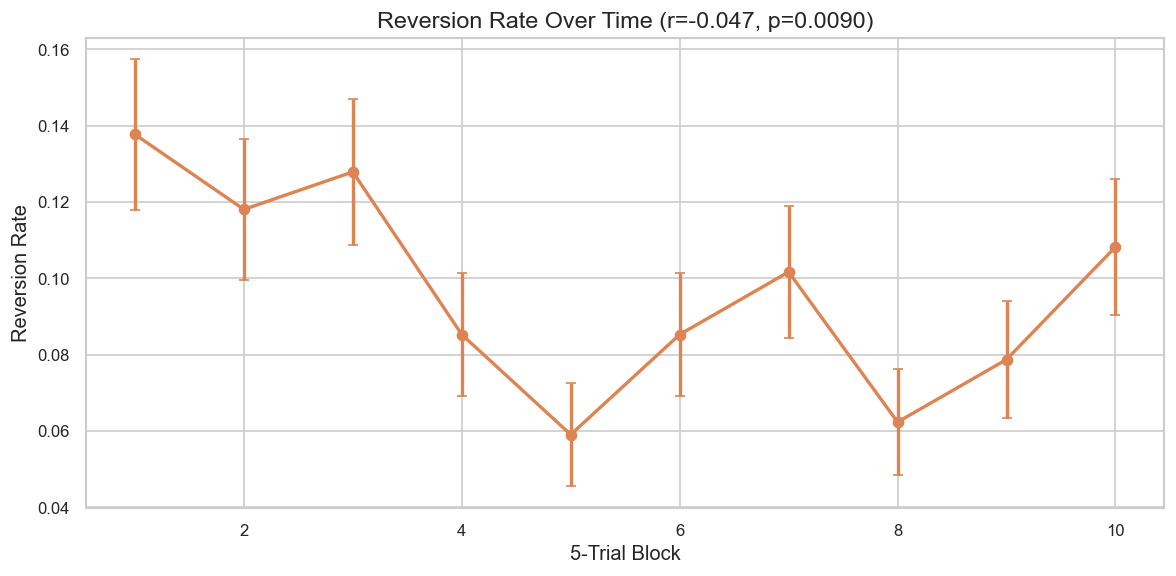

Reversion trend: r=-0.047, p=0.0090
  Positive r = increasing reversions over time


In [9]:
# Reversion rate over time (AI trials only)
ai_with_rev = ai_trials[ai_trials['reverted_decision'].notna()].copy()
ai_with_rev['reverted_float'] = ai_with_rev['reverted_decision'].astype(float)
ai_with_rev['block_5'] = pd.cut(ai_with_rev['within_phase_trial'],
                                bins=range(0, 55, 5), labels=range(1, 11))

rev_trend = ai_with_rev.groupby('block_5')['reverted_float'].agg(['mean', 'sem'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(rev_trend.index.astype(int), rev_trend['mean'], yerr=rev_trend['sem'],
           marker='o', color=COLORS['ai'], linewidth=2, capsize=3)
ax.set_xlabel('5-Trial Block')
ax.set_ylabel('Reversion Rate')

r_rev, p_rev = stats.pearsonr(
    ai_with_rev['within_phase_trial'].dropna(),
    ai_with_rev['reverted_float'].dropna()
)
ax.set_title(f'Reversion Rate Over Time (r={r_rev:.3f}, p={p_rev:.4f})')

plt.tight_layout()
plt.show()

print(f'Reversion trend: r={r_rev:.3f}, p={p_rev:.4f}')
print(f'  Positive r = increasing reversions over time')

## 8. AI Deliberation Time: Mechanism Investigation

§8. AI Deliberation Time: Are Participants Shortcutting?

── M1: Following AI vs Rejecting AI → Trial Duration ──
  Followed AI:  M=24.78s, SD=15.59s, n=2014
  Rejected AI:  M=25.54s, SD=15.49s, n=1036
  Difference:   -0.76s
  t-test (2-sided): t=-1.285, p=0.1987
  Mann-Whitney (followed < rejected): U=997086.5, p=0.0225

  → No significant difference in decision time by AI agreement.

── Duration for Correct vs Incorrect Decisions (AI trials) ──
  Correct: M=24.88s | Wrong: M=25.34s
  t=-0.769, p=0.4420

── M2: Increasing AI Reliance → Increasing Speed-Up? ──
  Spearman r=-0.020, p=0.8756
  (Negative r = more reliance growth → more speed-up, i.e. trust shortcut accumulates)

── M3: Is Speed-Up Stronger in AI Than Control? ──
  Control speed-up:  M=-3.68s
  AI speed-up:       M=-18.25s
  Difference:        -14.57s
  t-test: t=-8.904, p=0.0000
  → AI condition produces SIGNIFICANTLY MORE speed-up than Control.
    This is condition-specific, not pure task habituation.

── Mixed Model: t

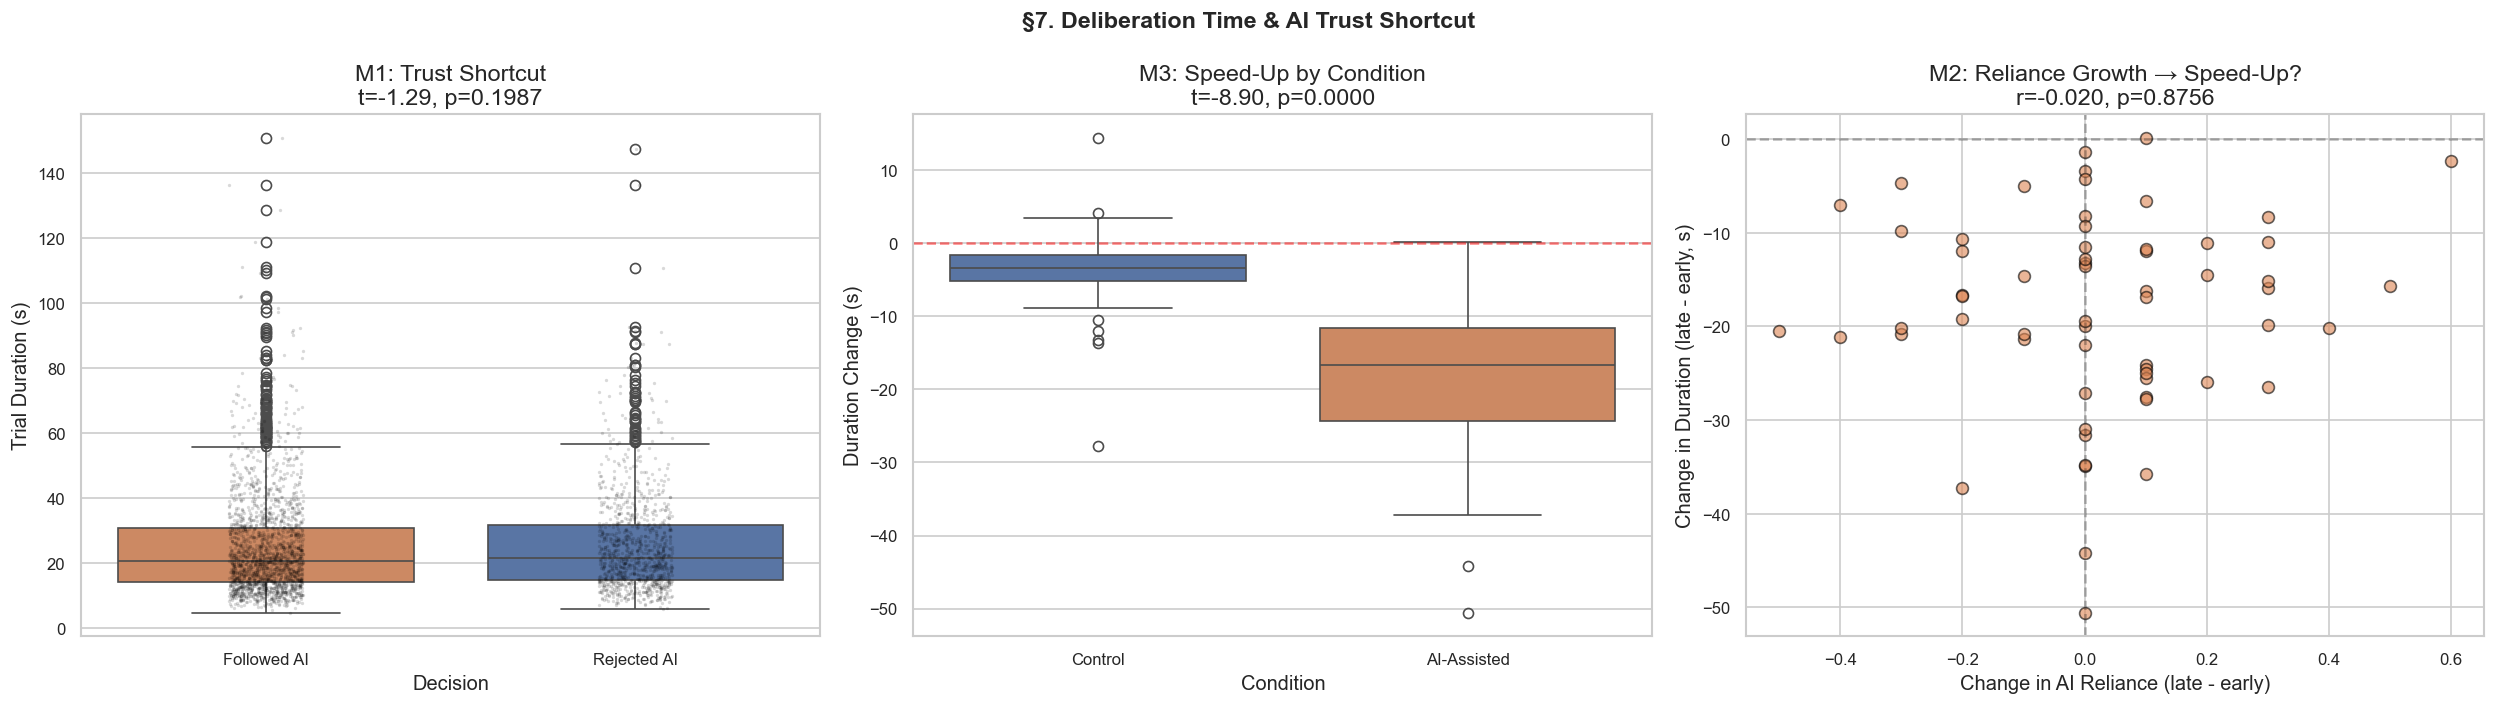

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, spearmanr, mannwhitneyu
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── M1: Does following the AI = faster decision than rejecting? ──
ai_trials = df[df['ai_shown'] == True].copy()
ai_trials['followed_ai'] = ai_trials['agreed_with_ai'] == 1.0

followed = ai_trials[ai_trials['followed_ai'] == True]['trial_duration']
rejected = ai_trials[ai_trials['followed_ai'] == False]['trial_duration']

t_m1, p_m1 = ttest_ind(followed.dropna(), rejected.dropna())
u_m1, pu_m1 = mannwhitneyu(followed.dropna(), rejected.dropna(), alternative='less')

print("§8. AI Deliberation Time: Are Participants Shortcutting?")
print()
print("── M1: Following AI vs Rejecting AI → Trial Duration ──")
print(f"  Followed AI:  M={followed.mean():.2f}s, SD={followed.std():.2f}s, n={len(followed)}")
print(f"  Rejected AI:  M={rejected.mean():.2f}s, SD={rejected.std():.2f}s, n={len(rejected)}")
print(f"  Difference:   {followed.mean() - rejected.mean():+.2f}s")
print(f"  t-test (2-sided): t={t_m1:.3f}, p={p_m1:.4f}")
print(f"  Mann-Whitney (followed < rejected): U={u_m1:.1f}, p={pu_m1:.4f}")
print()
if p_m1 < 0.05:
    if followed.mean() < rejected.mean():
        print("  → TRUST SHORTCUT confirmed: following AI is faster than rejecting it.")
        print("    Participants deliberate LESS when they agree with AI.")
    else:
        print("  → UNEXPECTED: rejecting AI is faster than following it.")
else:
    print("  → No significant difference in decision time by AI agreement.")
print()

# ── Also check: correct vs incorrect decisions ──
correct_dur = ai_trials[ai_trials['user_correct'] == 1.0]['trial_duration']
wrong_dur   = ai_trials[ai_trials['user_correct'] == 0.0]['trial_duration']
t_corr, p_corr = ttest_ind(correct_dur.dropna(), wrong_dur.dropna())
print("── Duration for Correct vs Incorrect Decisions (AI trials) ──")
print(f"  Correct: M={correct_dur.mean():.2f}s | Wrong: M={wrong_dur.mean():.2f}s")
print(f"  t={t_corr:.3f}, p={p_corr:.4f}")
print()

# ── M2: Participant-level — does increasing AI reliance → more speed-up? ──
# Compute per-participant: delta reliance (late - early) & delta duration (late - early)
def get_temporal_change(grp, col, first_n=10, last_n=10):
    grp_sorted = grp.sort_values('trial_end_time')
    first = grp_sorted.head(first_n)[col].mean()
    last  = grp_sorted.tail(last_n)[col].mean()
    return last - first

ai_by_p = (
    df[df['ai_shown'] == True]
    .groupby('participant_id')
    .apply(lambda g: pd.Series({
        'reliance_change': get_temporal_change(g, 'agreed_with_ai'),
        'duration_change': get_temporal_change(g, 'trial_duration'),
    }))
    .reset_index()
)

r_m2, p_m2 = spearmanr(
    ai_by_p['reliance_change'].dropna(),
    ai_by_p.loc[ai_by_p['reliance_change'].notna(), 'duration_change']
)
print("── M2: Increasing AI Reliance → Increasing Speed-Up? ──")
print(f"  Spearman r={r_m2:.3f}, p={p_m2:.4f}")
print(f"  (Negative r = more reliance growth → more speed-up, i.e. trust shortcut accumulates)")
print()

# ── M3: Is speed-up condition-specific or universal? ──
ctrl_by_p = (
    df[df['ai_shown'] == False]
    .groupby('participant_id')
    .apply(lambda g: pd.Series({
        'duration_change_ctrl': get_temporal_change(g, 'trial_duration'),
    }))
    .reset_index()
)
ai_speed = ai_by_p[['participant_id', 'duration_change']].rename(
    columns={'duration_change': 'duration_change_ai'}
)
both = ctrl_by_p.merge(ai_speed, on='participant_id', how='inner')
t_m3, p_m3 = ttest_ind(
    both['duration_change_ai'].dropna(),
    both['duration_change_ctrl'].dropna()
)
print("── M3: Is Speed-Up Stronger in AI Than Control? ──")
print(f"  Control speed-up:  M={both['duration_change_ctrl'].mean():.2f}s")
print(f"  AI speed-up:       M={both['duration_change_ai'].mean():.2f}s")
print(f"  Difference:        {both['duration_change_ai'].mean() - both['duration_change_ctrl'].mean():+.2f}s")
print(f"  t-test: t={t_m3:.3f}, p={p_m3:.4f}")
if p_m3 < 0.05:
    print("  → AI condition produces SIGNIFICANTLY MORE speed-up than Control.")
    print("    This is condition-specific, not pure task habituation.")
else:
    print("  → Speed-up is not significantly different between conditions.")
print()

# ── Mixed model: Duration ~ is_ai × within_phase_trial (the interaction) ──
df_lm = df[['trial_duration','ai_shown','participant_id']].copy()
df_lm['is_ai'] = df_lm['ai_shown'].astype(int)
df_lm['within_phase_trial'] = (
    df.groupby('participant_id').cumcount() % 50 + 1
)
df_lm = df_lm.dropna()

try:
    import statsmodels.formula.api as smf
    model = smf.mixedlm(
        "trial_duration ~ is_ai * within_phase_trial",
        df_lm,
        groups=df_lm["participant_id"]
    ).fit(reml=False)
    print("── Mixed Model: trial_duration ~ is_ai × within_phase_trial ──")
    results = model.summary().tables[1]
    key_rows = ['is_ai', 'within_phase_trial', 'is_ai:within_phase_trial']
    for row in key_rows:
        try:
            coef = model.params[row]
            pval = model.pvalues[row]
            se   = model.bse[row]
            sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
            print(f"  {row:<35} β={coef:+.3f}  SE={se:.3f}  p={pval:.4f}  {sig}")
        except KeyError:
            pass
    print()
    print("  ⚠  Key coefficient: is_ai:within_phase_trial")
    print("     Negative & significant = AI condition speeds up FASTER over time")
    print("     This confirms the AI shortcutting is progressive, not just a level shift")
except Exception as e:
    print(f"Mixed model error: {e}")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# M1: Box plot of duration by AI agreement
dur_data = pd.DataFrame({
    'Decision': ['Followed AI'] * len(followed) + ['Rejected AI'] * len(rejected),
    'Trial Duration (s)': list(followed) + list(rejected)
})
sns.boxplot(data=dur_data, x='Decision', y='Trial Duration (s)', ax=axes[0],
            palette=[COLORS['ai'], COLORS['control']])
sns.stripplot(data=dur_data, x='Decision', y='Trial Duration (s)', ax=axes[0],
              color='black', alpha=0.15, size=2)
axes[0].set_title(f'M1: Trust Shortcut\nt={t_m1:.2f}, p={p_m1:.4f}')

# M3: Speed-up in AI vs Control
speedup_data = pd.DataFrame({
    'Condition': ['Control'] * len(both) + ['AI-Assisted'] * len(both),
    'Duration Change (s)': list(both['duration_change_ctrl']) + list(both['duration_change_ai'])
})
sns.boxplot(data=speedup_data, x='Condition', y='Duration Change (s)', ax=axes[1],
            palette=[COLORS['control'], COLORS['ai']])
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title(f'M3: Speed-Up by Condition\nt={t_m3:.2f}, p={p_m3:.4f}')

# M2: Scatter: reliance change vs duration change
axes[2].scatter(ai_by_p['reliance_change'], ai_by_p['duration_change'],
                c=COLORS['ai'], edgecolors='black', alpha=0.6, s=50)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[2].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[2].set_xlabel('Change in AI Reliance (late - early)')
axes[2].set_ylabel('Change in Duration (late - early, s)')
axes[2].set_title(f'M2: Reliance Growth → Speed-Up?\nr={r_m2:.3f}, p={p_m2:.4f}')

plt.suptitle('§7. Deliberation Time & AI Trust Shortcut', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Findings & Next Steps

**Summarize after running:**

1. Learning curves: is there improvement over trials?
2. Speed trends: are participants speeding up (fatigue/disengagement)?
3. Fatigue crash: any sharp drop-off point?
4. AI reliance drift: does over-reliance increase with fatigue?
5. Carry-over effects: does Phase 1 condition affect Phase 2?
6. Reversion trends over time

**Next**: NB4 for psychometric analysis.